In [1]:
%%bash
mkdir -p genome_alignment_prac/{data,results}
cd genome_alignment_prac/data

curl -s -L -o ecoli_k12.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.fna.gz"
curl -s -L -o ecoli_k12.gbff.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"
curl -s -L -o ecoli_o157.fna.gz "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/008/865/GCF_000008865.2_ASM886v2/GCF_000008865.2_ASM886v2_genomic.fna.gz"

gunzip -f *.gz

cd ../results

nucmer --prefix=ecoli_opt --maxmatch --mincluster=100 --diagfactor=0.12 ../data/ecoli_k12.fna ../data/ecoli_o157.fna

delta-filter -1 -i 90 ecoli_opt.delta > ecoli_filt.delta

show-snps -C -T -r ecoli_filt.delta > ecoli_snps.tsv

head -n 5 ecoli_snps.tsv

/Users/abbiasov91/Desktop/биоинформатика/task_3/genome_alignment_prac/data/ecoli_k12.fna /Users/abbiasov91/Desktop/биоинформатика/task_3/genome_alignment_prac/data/ecoli_o157.fna
NUCMER

[P1]	[SUB]	[SUB]	[P2]	[BUFF]	[DIST]	[FRM]	[TAGS]
58	G	C	58	6	58	1	1	NC_000913.3	NC_002695.2


| Столбец | Название | Описание |
|---------|----------|----------|
| 1 | `P1` | Позиция нуклеотида в референсной последовательности (1-индексация) |
| 2 | `SUB` | Нуклеотид в референсе в данной позиции |
| 3 | `SUB` | Нуклеотид в запросной последовательности (альтернативная аллель) |
| 4 | `P2` | Позиция нуклеотида в запросной последовательности |
| 5 | `BUFF` | Расстояние до ближайшего соседнего несовпадения (SNP) в пределах того же выравнивания |
| 6 | `DIST` | Расстояние от данной позиции до конца выравнивания |
| 7 | `FRM` | Рамка считывания: 1,2,3 – прямая цепь; -1,-2,-3 – комплементарная цепь |
| 8 | `TAGS` | Содержит две текстовые колонки: ID референсной последовательности (NC_000913.3) и ID исследуемой последовательности (NC_002695.2). |

In [15]:
import pandas as pd
from Bio import SeqIO
from Bio.Seq import Seq
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Генетический код для бактерий (таблица 11)
GENETIC_CODE = 11

In [5]:
GB_FILE = "genome_alignment_prac/data/ecoli_k12.gbff"

record = SeqIO.read(GB_FILE, "genbank")
genome_seq = record.seq


cds_features = [f for f in record.features if f.type == "CDS"]
print(f"Загружено CDS: {len(cds_features)}")

Загружено CDS: 4318


In [6]:
SNP_FILE = "genome_alignment_prac/results/ecoli_snps.tsv"

snps_df = pd.read_csv(SNP_FILE, sep='\t', skiprows=4, header=None)
snps_df.columns = ['P1', 'REF', 'ALT', 'P2', 'BUFF', 'DIST', 'FRM_R', 'FRM_Q', 'TAG_R', 'TAG_Q']

print(f"Загружено SNP: {len(snps_df)}")
snps_df.head()

Загружено SNP: 73270


,P1,REF,ALT,P2,BUFF,DIST,FRM_R,FRM_Q,TAG_R,TAG_Q
0,58,G,C,58,6,58,1,1,NC_000913.3,NC_002695.2
1,64,T,C,64,6,64,1,1,NC_000913.3,NC_002695.2
2,228,.,A,229,0,228,1,1,NC_000913.3,NC_002695.2
3,228,.,C,230,0,228,1,1,NC_000913.3,NC_002695.2
4,228,.,C,231,0,228,1,1,NC_000913.3,NC_002695.2


In [7]:
def get_affected_cds(pos_1based, cds_features, genome_seq):
    """
    Находит все CDS, перекрывающие заданную позицию (1-включительно).
    Возвращает список словарей с информацией о каждой CDS.
    """
    target_pos = pos_1based - 1  
    affected = []
    for feat in cds_features:
        if target_pos not in feat.location:
            continue
        
        cds_seq = feat.extract(genome_seq)
        if feat.location.strand == 1:
            idx_in_cds = target_pos - feat.location.start
        else:
            idx_in_cds = feat.location.end - 1 - target_pos 

        
        if idx_in_cds < 0 or idx_in_cds >= len(cds_seq):
            continue

        gene = feat.qualifiers.get('gene', [None])[0]
        locus_tag = feat.qualifiers.get('locus_tag', [None])[0]
        product = feat.qualifiers.get('product', ['Unknown'])[0]
        gene_name = gene if gene else locus_tag if locus_tag else "Unknown"

        affected.append({
            'feature': feat,
            'gene_name': gene_name,
            'product': product,
            'strand': feat.location.strand,
            'cds_seq': cds_seq,
            'idx_in_cds': idx_in_cds
        })
    return affected

def translate_codon(codon_seq):
    """Безопасная трансляция кодона с обработкой ошибок."""
    try:
        return str(codon_seq.translate(table=GENETIC_CODE))
    except:
        return '?'

def analyze_snp(pos, ref, alt, cds_features, genome_seq):
    """
    Анализирует один SNP. Возвращает список словарей с результатами.
    """
    results = []
    cds_list = get_affected_cds(pos, cds_features, genome_seq)

    if not cds_list:
        results.append({
            'Position': pos,
            'Ref': ref,
            'Alt': alt,
            'Gene': 'Intergenic',
            'Product': 'None',
            'Type': 'Intergenic',
            'AA_Change': '-'
        })
        return results

    for cds_info in cds_list:
        strand = cds_info['strand']
        cds_seq = cds_info['cds_seq']
        idx = cds_info['idx_in_cds']

        # Кодон, в который попадает мутация
        codon_start = (idx // 3) * 3
        ref_codon = cds_seq[codon_start:codon_start+3]
        pos_in_codon = idx - codon_start

        # Определяем альтернативный аллель на смысловой цепи
        if strand == 1:
            sense_alt = alt
        else:
            sense_alt = str(Seq(alt).complement())

        # Мутированный кодон
        alt_codon_list = list(ref_codon)
        alt_codon_list[pos_in_codon] = sense_alt
        alt_codon = Seq("".join(alt_codon_list))

        ref_aa = translate_codon(ref_codon)
        alt_aa = translate_codon(alt_codon)

        # Классификация
        if ref_aa == '?' or alt_aa == '?':
            snp_type = "Translation Error"
        elif ref_aa == alt_aa:
            snp_type = "Synonymous"
        else:
            snp_type = "Non-synonymous"
            if alt_aa == '*':
                snp_type += " (nonsense)"
            if codon_start == 0 and ref_aa == 'M' and alt_aa != 'M':
                snp_type += " (start-lost)"

        aa_pos = (idx // 3) + 1
        aa_change = f"p.{ref_aa}{aa_pos}{alt_aa}"

        results.append({
            'Position': pos,
            'Ref': ref,
            'Alt': alt,
            'Gene': cds_info['gene_name'],
            'Product': cds_info['product'],
            'Type': snp_type,
            'AA_Change': aa_change
        })
    return results



In [8]:
all_annotations = []

for _, row in snps_df.iterrows():
    pos = int(row['P1'])
    ref = str(row['REF']).upper()
    alt = str(row['ALT']).upper()

    if len(ref) != 1 or len(alt) != 1:
        continue

    results = analyze_snp(pos, ref, alt, cds_features, genome_seq)
    all_annotations.extend(results)

print(f"Обработано вариантов: {len(all_annotations)}")

Обработано вариантов: 73469


In [23]:
anno_df = pd.DataFrame(all_annotations)
anno_df = anno_df.sort_values(['Position', 'Gene']).reset_index(drop=True)


OUTPUT_FILE = "snp_annotations.tsv"
anno_df.to_csv(OUTPUT_FILE, sep='\t', index=False)


In [22]:

anno_df.head(10)

,Position,Ref,Alt,Gene,Product,Type,AA_Change
0,58,G,C,Intergenic,None,Intergenic,-
1,64,T,C,Intergenic,None,Intergenic,-
2,228,.,A,thrL,thr operon leader peptide,Synonymous,p.T13T
3,228,.,C,thrL,thr operon leader peptide,Synonymous,p.T13T
4,228,.,C,thrL,thr operon leader peptide,Synonymous,p.T13T
5,228,.,A,thrL,thr operon leader peptide,Synonymous,p.T13T
6,228,.,C,thrL,thr operon leader peptide,Synonymous,p.T13T
7,228,.,C,thrL,thr operon leader peptide,Synonymous,p.T13T
8,228,.,A,thrL,thr operon leader peptide,Synonymous,p.T13T
9,228,.,T,thrL,thr operon leader peptide,Synonymous,p.T13T


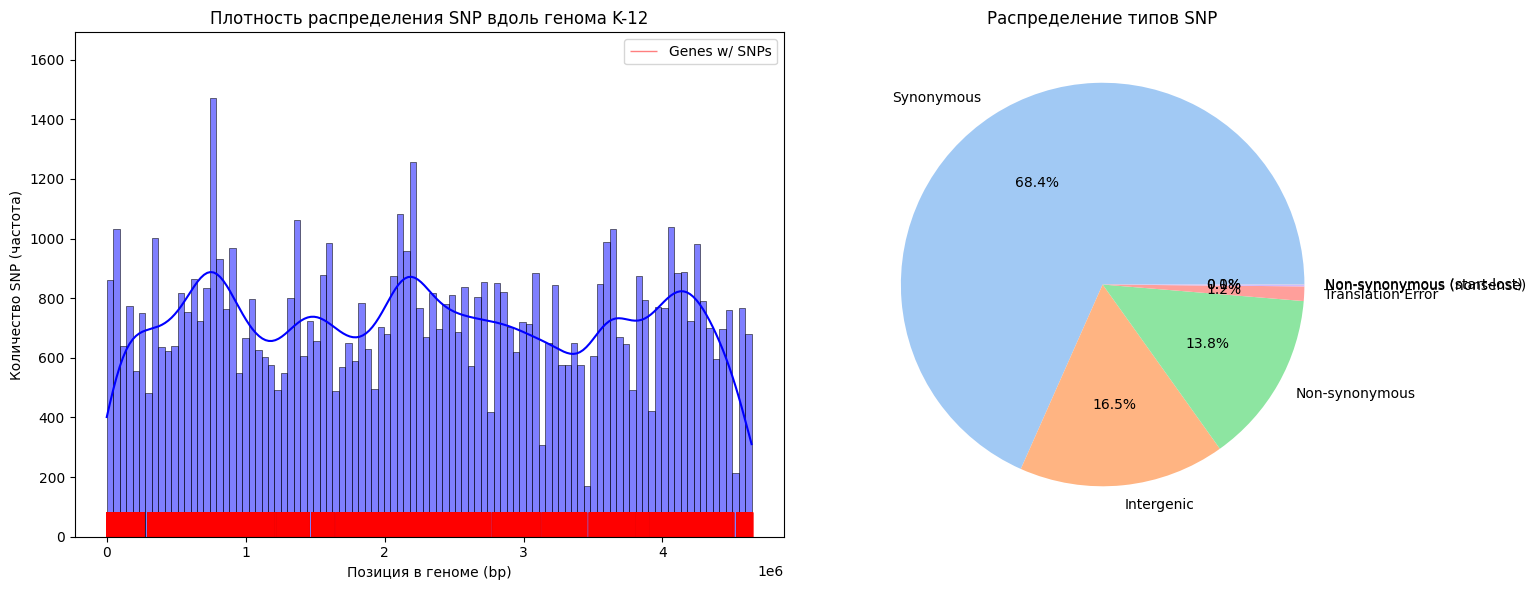

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Левая панель: плотность SNP вдоль генома ---
sns.histplot(anno_df['Position'], bins=100, kde=True, color='blue', ax=axes[0])

# Отметки позиций SNP, попавших в гены (красные риски снизу)
gene_snp_positions = anno_df[anno_df['Gene'] != 'Intergenic']['Position']
sns.rugplot(gene_snp_positions, height=0.05, color='red', ax=axes[0], alpha=0.5, label='Genes w/ SNPs')

axes[0].set_title('Плотность распределения SNP вдоль генома K-12')
axes[0].set_xlabel('Позиция в геноме (bp)')
axes[0].set_ylabel('Количество SNP (частота)')
axes[0].legend()

# --- Правая панель: распределение типов мутаций ---
type_counts = anno_df['Type'].value_counts()
# Используем палитру, которая автоматически подстраивается под количество категорий
colors = sns.color_palette('pastel', n_colors=len(type_counts))
axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Распределение типов SNP')

plt.tight_layout()
plt.show()

In [19]:
# Топ-10 генов с наибольшим числом SNP
print("=== Топ-10 генов с наибольшим количеством SNP ===")
top10_genes = anno_df[anno_df['Gene'] != 'Intergenic']['Gene'].value_counts().head(10).reset_index()
top10_genes.columns = ['Ген', 'Количество SNP']
display(top10_genes)

=== Топ-10 генов с наибольшим количеством SNP ===


,Ген,Количество SNP
0,ybgQ,437
1,yeeJ,250
2,ybgO,225
3,yehI,194
4,yjgL,187
5,ybgP,182
6,yfaL,141
7,entF,131
8,cpsB,122
9,yccE,116


## Часть 3. Поиск функционально значимых SNP 

Выбранная тема -  Идентификация мутаций в генах устойчивости к антибиотикам.


Первая часть(из литературы) - мутации в целевых генах из статей (marR, gyrA, hisD, parC)

In [20]:
literature_targets = ['marR', 'gyrA', 'hisD', 'parC']

# Фильтруем аннотацию – показываем все SNP в этих генах (не только несинонимичные)
literature_snps = anno_df[anno_df['Gene'].isin(literature_targets)].copy()

if literature_snps.empty:
    print("В указанных локусах (marR, gyrA, hisD, parC) SNP не обнаружены.")
else:
    print(f"=== Найдено {literature_snps.shape[0]} SNP в известных генах устойчивости ===")
    # Выделим подмножество несинонимичных – они представляют наибольший интерес
    nonsyn_mask = literature_snps['Type'].str.contains('Non-synonymous', na=False)
    print(f"Из них несинонимичных: {nonsyn_mask.sum()}")
    display(literature_snps.sort_values(['Gene', 'Position']))


=== Найдено 108 SNP в известных генах устойчивости ===
Из них несинонимичных: 12


,Position,Ref,Alt,Gene,Product,Type,AA_Change
38054,2336991,C,T,gyrA,DNA gyrase subunit A,Synonymous,p.S810S
38055,2337132,G,A,gyrA,DNA gyrase subunit A,Synonymous,p.T763T
38056,2337135,T,C,gyrA,DNA gyrase subunit A,Synonymous,p.P762P
38057,2337165,G,A,gyrA,DNA gyrase subunit A,Synonymous,p.Y752Y
38058,2337174,T,C,gyrA,DNA gyrase subunit A,Synonymous,p.Q749Q
...,...,...,...,...,...,...,...
50916,3164936,G,A,parC,DNA topoisomerase IV subunit A,Synonymous,p.I346I
50917,3164996,A,G,parC,DNA topoisomerase IV subunit A,Synonymous,p.R326R
50918,3165086,G,A,parC,DNA topoisomerase IV subunit A,Synonymous,p.R296R
50919,3165568,G,A,parC,DNA topoisomerase IV subunit A,Synonymous,p.L136L


In [21]:

resistance_genes = [
    # Эффлюкс-помпы (AcrAB-TolC и другие)
    'acrA', 'acrB', 'acrD', 'acrE', 'acrF', 'acrR', 'acrZ',
    'tolC', 'mdfA', 'emrA', 'emrB', 'emrR', 'bcr',
    # Бета-лактамазы
    'ampC', 'ampE', 'ampH',
    # Регуляторы множественной лекарственной устойчивости (mar, sox, rob)
    'marA', 'marB', 'marR', 'marC',
    'soxS', 'soxR', 'robA',
    # Модификация мишеней (гиразы и топоизомеразы – уже частично проверены выше,
    # но включим gyrB, parE для полноты)
    'gyrA', 'gyrB', 'parC', 'parE',
    # Устойчивость к полимиксинам (модификация ЛПС)
    'arnA', 'arnB', 'arnC', 'arnD', 'arnE', 'arnF', 'arnT',
    # Дополнительно: гены, кодирующие порины (потеря мутаций в них часто снижает проницаемость)
    'ompF', 'ompC', 'ompR', 'envZ',
    # Транс-факторы и другие белки, связанные с ответом на стресс
    'rpoB', 'rpoS', 'recA'
]

# Отбираем только несинонимичные мутации в этих генах
nonsyn_resistance = anno_df[
    (anno_df['Gene'].isin(resistance_genes)) & 
    (anno_df['Type'].str.contains('Non-synonymous', na=False))
].copy()

if nonsyn_resistance.empty:
    print("Не найдено новых несинонимичных SNP в расширенном списке генов резистентности.")
else:
    print(f"=== Найдено {nonsyn_resistance.shape[0]} несинонимичных SNP в генах резистентности ===")
    display(nonsyn_resistance.sort_values(['Gene', 'AA_Change']))


=== Найдено 121 несинонимичных SNP в генах резистентности ===


,Position,Ref,Alt,Gene,Product,Type,AA_Change
7578,481276,C,T,acrB,multidrug efflux pump RND permease AcrB,Non-synonymous,p.S1043N
7604,484019,C,T,acrB,multidrug efflux pump RND permease AcrB,Non-synonymous,p.V129I
42308,2587973,G,T,acrD,multidrug efflux pump RND permease AcrD,Non-synonymous,p.V127L
42315,2588397,T,C,acrD,multidrug efflux pump RND permease AcrD,Non-synonymous,p.V268A
54337,3414861,C,T,acrE,multidrug efflux pump membrane fusion lipoprot...,Non-synonymous,p.A333V
...,...,...,...,...,...,...,...
16806,986306,G,A,ompF,outer membrane porin F,Non-synonymous,p.P226L
16802,986177,G,A,ompF,outer membrane porin F,Non-synonymous,p.T269I
51030,3174933,G,T,parE,DNA topoisomerase IV subunit B,Non-synonymous,p.T155N
46669,2867455,G,C,rpoS,RNA polymerase sigma factor RpoS,Non-synonymous,p.Q33E


Проведенный анализ позволил выявить мутации, потенциально связанные с устойчивостью к антибиотикам.

1. Проверка известных маркеров (marR, gyrA, hisD, parC)

* В четырех целевых генах обнаружено 108 SNP, однако подавляющее большинство из них (96) оказались синонимичными.
* Выявлено всего 12 несинонимичных замен. Этот факт указывает на то, что данные гены находятся под сильным эволюционным давлением – большинство изменений в них "запрещены", так как нарушают жизненно важные функции. Обнаруженные единичные несинонимичные SNP могут представлять собой потенциальные мутации устойчивости, которые стоит проверить экспериментально.
* Преобладание синонимичных замен также может говорить о естественном дрейфе или о том, что лабораторный штамм K-12 не подвергался интенсивному селективному давлению этими антибиотиками.

## Применение результатов анализа в реальной жизни

1. Клиническая микробиология и диагностика

* Разработка молекулярных тестов: найденные несинонимичные SNP  могут стать мишенями для создания ПЦР-тестов. Вместо длительного культивирования можно за несколько часов понять, есть ли у бактерии генетическая предрасположенность к резистентности.
* Мониторинг эпидемиологии: обнаружение характерных мутаций помогает отслеживать распространение устойчивых клонов в больницах и за их пределами.
